In [333]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [334]:
MAK = pd.read_csv("D:/M2_INOHA/DATA_SCIENCE/DATA-SCIENCE_M2_INOHA/INOHA-DataScience-M2/donnees_mpox_RDC_3000.csv")
MAK

,ID,Semaine,Province,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Saison,Population_Risque,Taux_Positivite_pct
0,OBS_00001,1,Mongala,206,24.4,0.480,64,39,31.8,150,22,1,4,29,Pluie,3478,19.33
1,OBS_00002,2,Kinshasa,56,23.7,0.474,74,107,24.9,300,5,1,6,42,Seche,3713,14.00
2,OBS_00003,3,Kinshasa,59,25.2,0.333,62,140,53.9,310,16,0,8,20,Seche,4833,6.45
3,OBS_00004,4,Mai-Ndombe,396,24.1,0.354,68,97,25.9,210,4,0,10,82,Pluie,3777,39.05
4,OBS_00005,5,Kasaï,127,19.8,0.303,61,86,30.3,260,24,1,6,24,Pluie,9396,9.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,OBS_02996,2996,Kongo Central,271,31.6,0.534,88,57,22.4,220,33,1,7,125,Pluie,3166,56.82
2996,OBS_02997,2997,Sud-Ubangi,88,24.6,0.262,95,47,34.1,370,7,1,6,70,Seche,6099,18.92
2997,OBS_02998,2998,Bas-Uele,268,25.6,0.720,58,18,41.9,190,23,0,2,36,Pluie,5475,18.95
2998,OBS_02999,2999,Haut-Uele,211,24.9,0.196,77,28,10.6,370,2,0,2,160,Pluie,4813,43.24


In [335]:
print("Aperçu des données épidémiologiques :")
print(MAK.head(10))

Aperçu des données épidémiologiques :
          ID  Semaine       Province  Pluviometrie_mm  Temperature_C   NDVI  \
0  OBS_00001        1        Mongala              206           24.4  0.480   
1  OBS_00002        2       Kinshasa               56           23.7  0.474   
2  OBS_00003        3       Kinshasa               59           25.2  0.333   
3  OBS_00004        4     Mai-Ndombe              396           24.1  0.354   
4  OBS_00005        5          Kasaï              127           19.8  0.303   
5  OBS_00006        6        Tshuapa              400           20.6  0.721   
6  OBS_00007        7  Kongo Central              181           26.6  0.779   
7  OBS_00008        8         Kwango              356           22.9  0.607   
8  OBS_00009        9         Tshopo              252           30.3  0.527   
9  OBS_00010       10          Kwilu               27           22.1  0.608   

   Humidite_pct  Densite_Population  Couverture_Vaccinale_pct  Tests_Realises  \
0          

## STATISTIQUES DESCRIPTIVES

In [336]:
print("\nStatistiques descriptives :")
print(MAK.describe())


Statistiques descriptives :
           Semaine  Pluviometrie_mm  Temperature_C         NDVI  Humidite_pct  \
count  3000.000000      3000.000000    3000.000000  3000.000000   3000.000000   
mean   1500.500000       157.779667      24.980367     0.451182     71.571667   
std     866.169729       101.958774       3.832510     0.157799     11.625285   
min       1.000000         2.000000      18.000000     0.103000     40.000000   
25%     750.750000        77.000000      22.300000     0.331000     64.000000   
50%    1500.500000       136.000000      24.900000     0.452000     71.500000   
75%    2250.250000       221.000000      27.600000     0.576000     80.000000   
max    3000.000000       400.000000      34.000000     0.795000     95.000000   

       Densite_Population  Couverture_Vaccinale_pct  Tests_Realises  \
count         3000.000000               3000.000000     3000.000000   
mean           119.100333                 31.843967      286.143333   
std             95.218460   

In [337]:
# ======================================================
# VARIABLES DU MODELE DE REGRESSION MULTIPLE
# ======================================================


variables_X = [

    'Pluviometrie_mm',
    'Temperature_C',
    'NDVI',
    'Humidite_pct',
    'Densite_Population',
    'Couverture_Vaccinale_pct',
    'Tests_Realises',
    'Distance_Centre_Sante_km',
    'Reservoirs_Animaux',
    'Mobilite_Humaine'

]


X = MAK[variables_X]


y = MAK['Cas_Confirmes']

### Vérification des données manquantes

In [338]:
MAK[variables_X + ['Cas_Confirmes']].isnull().sum()

Pluviometrie_mm             0
Temperature_C               0
NDVI                        0
Humidite_pct                0
Densite_Population          0
Couverture_Vaccinale_pct    0
Tests_Realises              0
Distance_Centre_Sante_km    0
Reservoirs_Animaux          0
Mobilite_Humaine            0
Cas_Confirmes               0
dtype: int64

In [339]:
MAK = MAK.dropna(
    subset=variables_X + ['Cas_Confirmes']
)

### Séparation apprentissage/test

In [340]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

### Ajustement du modèle de régression multiple

In [341]:
from sklearn.linear_model import LinearRegression


modele_reg = LinearRegression()


modele_reg.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 0.43, 2.59,60.79,...,-0.82,-2.64,-0.06]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['Pluviometrie_mm','Temperature_C','NDVI',...,'Distance_Centre_Sante_km', 'Reservoirs_Animaux','Mobilite_Humaine']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-158
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)


### Prédiction

In [342]:
y_pred = modele_reg.predict(
    X_test
)

### Évaluation du modèle

In [343]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import numpy as np


print(
    "MSE :",
    mean_squared_error(y_test,y_pred)
)


print(
    "RMSE :",
    np.sqrt(
        mean_squared_error(y_test,y_pred)
    )
)


print(
    "MAE :",
    mean_absolute_error(y_test,y_pred)
)


print(
    "R² :",
    r2_score(y_test,y_pred)
)

MSE : 933.2965647013062
RMSE : 30.549902859114074
MAE : 22.150635752135194
R² : 0.8257566956370467


### 8. Interprétation des coefficients

In [344]:
coefficients = pd.DataFrame({

    "Variable": variables_X,

    "Coefficient": modele_reg.coef_

})


coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Variable,Coefficient
2,NDVI,60.792604
1,Temperature_C,2.589671
0,Pluviometrie_mm,0.426789
3,Humidite_pct,0.370582
6,Tests_Realises,0.361191
4,Densite_Population,0.142401
9,Mobilite_Humaine,-0.063845
7,Distance_Centre_Sante_km,-0.819687
5,Couverture_Vaccinale_pct,-1.721078
8,Reservoirs_Animaux,-2.637295


### Tableau final du modèle

In [345]:
import statsmodels.api as sm


X_sm = sm.add_constant(X)


modele_stats = sm.OLS(
    y,
    X_sm
).fit()


print(
    modele_stats.summary()
)

                            OLS Regression Results                            
Dep. Variable:          Cas_Confirmes   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     1383.
Date:                Sat, 18 Jul 2026   Prob (F-statistic):               0.00
Time:                        09:04:26   Log-Likelihood:                -14416.
No. Observations:                3000   AIC:                         2.885e+04
Df Residuals:                    2989   BIC:                         2.892e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

## MULTICOLINEARITE

In [346]:
# ==========================================================
# VERIFICATION DE LA MULTICOLINEARITE (VIF)
# ==========================================================

import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Variables explicatives
variables_X = [

    'Pluviometrie_mm',
    'Temperature_C',
    'NDVI',
    'Humidite_pct',
    'Densite_Population',
    'Couverture_Vaccinale_pct',
    'Tests_Realises',
    'Distance_Centre_Sante_km',
    'Reservoirs_Animaux',
    'Mobilite_Humaine'

]

# Matrice des variables explicatives
X = MAK[variables_X]

# Ajout de la constante
X_const = sm.add_constant(X)

# Calcul du VIF
vif = pd.DataFrame()

vif["Variable"] = X_const.columns

vif["VIF"] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]

# Affichage
print(vif.sort_values(by="VIF", ascending=False))

                    Variable         VIF
0                      const  118.060124
3                       NDVI    1.005431
7             Tests_Realises    1.004973
6   Couverture_Vaccinale_pct    1.004380
5         Densite_Population    1.004132
1            Pluviometrie_mm    1.003854
8   Distance_Centre_Sante_km    1.003341
4               Humidite_pct    1.002502
2              Temperature_C    1.002489
9         Reservoirs_Animaux    1.002390
10          Mobilite_Humaine    1.002005


In [347]:
# Arrondir les VIF
vif["VIF"] = vif["VIF"].round(2)

print(vif)

                    Variable     VIF
0                      const  118.06
1            Pluviometrie_mm    1.00
2              Temperature_C    1.00
3                       NDVI    1.01
4               Humidite_pct    1.00
5         Densite_Population    1.00
6   Couverture_Vaccinale_pct    1.00
7             Tests_Realises    1.00
8   Distance_Centre_Sante_km    1.00
9         Reservoirs_Animaux    1.00
10          Mobilite_Humaine    1.00


### Visualisation graphique des VIF

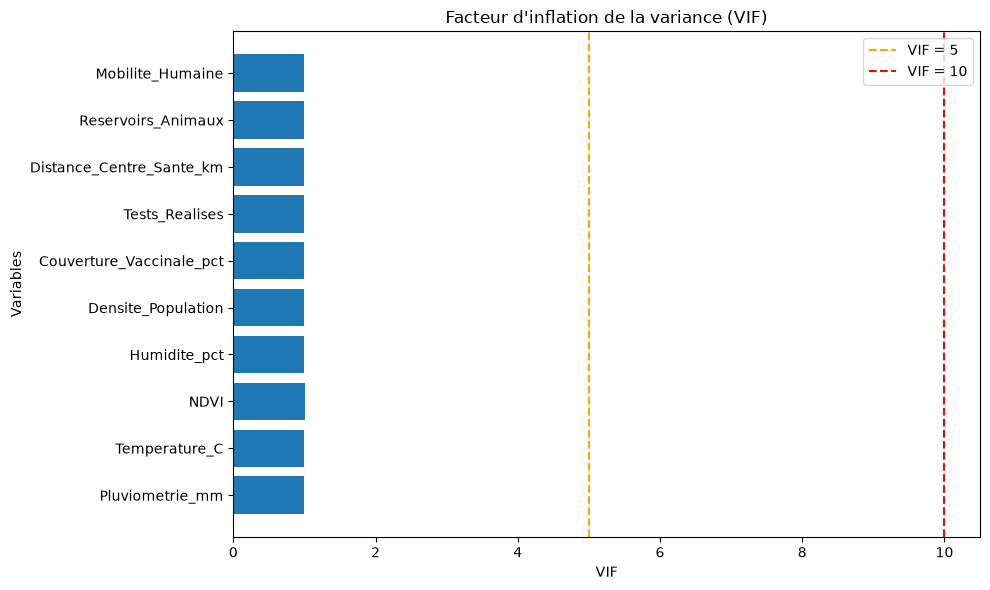

In [348]:
import matplotlib.pyplot as plt

vif_plot = vif[vif["Variable"] != "const"]

plt.figure(figsize=(10,6))

plt.barh(
    vif_plot["Variable"],
    vif_plot["VIF"]
)

plt.xlabel("VIF")
plt.ylabel("Variables")

plt.title("Facteur d'inflation de la variance (VIF)")

plt.axvline(
    x=5,
    color="orange",
    linestyle="--",
    label="VIF = 5"
)

plt.axvline(
    x=10,
    color="red",
    linestyle="--",
    label="VIF = 10"
)

plt.legend()

plt.tight_layout()

plt.show()

#### INTERPRETATION
##### Afin de vérifier l'absence de multicolinéarité entre les variables explicatives, le facteur d'inflation de la variance (Variance Inflation Factor, VIF) a été calculé pour chaque variable du modèle. Les résultats montrent que les valeurs de VIF sont comprises entre 1,00 et 1,01, ce qui est largement inférieur au seuil généralement admis de 5 (ou 10 selon certains auteurs). Ces résultats indiquent une absence de multicolinéarité significative entre les variables explicatives. Ainsi, les coefficients estimés par le modèle de régression multiple peuvent être interprétés avec confiance, sans risque d'instabilité lié à une forte corrélation entre les prédicteurs.

# 2. Analyse Exploratoire des Données (EDA) Approfondie

## 2.1. Statistiques Descriptives et Distribution

In [349]:
colonnes = ['Cas_Suspects', 'Cas_Confirmes']

for col in colonnes:
    if col in MAK.columns:
        print(f"{col} : OK")
    else:
        print(f"{col} : colonne absente")

Cas_Suspects : colonne absente
Cas_Confirmes : OK


In [350]:
for col in MAK.columns:
    if "cas" in col.lower():
        print(col)

Cas_Confirmes


In [351]:
print(MAK.columns.tolist())

['ID', 'Semaine', 'Province', 'Pluviometrie_mm', 'Temperature_C', 'NDVI', 'Humidite_pct', 'Densite_Population', 'Couverture_Vaccinale_pct', 'Tests_Realises', 'Distance_Centre_Sante_km', 'Reservoirs_Animaux', 'Mobilite_Humaine', 'Cas_Confirmes', 'Saison', 'Population_Risque', 'Taux_Positivite_pct']


In [352]:
print("Statistiques descriptives :")
print(MAK[['Cas_Confirmes']].describe())

Statistiques descriptives :
       Cas_Confirmes
count    3000.000000
mean       79.603333
std        70.119799
min         0.000000
25%        29.000000
50%        57.000000
75%       109.000000
max       479.000000


In [353]:
variables = [
    'Cas_Confirmes',
    'Tests_Realises',
    'Taux_Positivite_pct',
    'Pluviometrie_mm',
    'Temperature_C',
    'NDVI',
    'Humidite_pct',
    'Population_Risque'
]

print(MAK[variables].describe())

       Cas_Confirmes  Tests_Realises  Taux_Positivite_pct  Pluviometrie_mm  \
count    3000.000000     3000.000000          3000.000000      3000.000000   
mean       79.603333      286.143333            27.041943       157.779667   
std        70.119799       88.256194            20.156959       101.958774   
min         0.000000       90.000000             0.000000         2.000000   
25%        29.000000      220.000000            11.430000        77.000000   
50%        57.000000      280.000000            21.455000       136.000000   
75%       109.000000      340.000000            38.070000       221.000000   
max       479.000000      800.000000            95.000000       400.000000   

       Temperature_C         NDVI  Humidite_pct  Population_Risque  
count    3000.000000  3000.000000   3000.000000        3000.000000  
mean       24.980367     0.451182     71.571667        5471.297667  
std         3.832510     0.157799     11.625285        2636.188129  
min        18.000000 

In [354]:
print("Statistiques descriptives")
print(MAK.describe())

Statistiques descriptives
           Semaine  Pluviometrie_mm  Temperature_C         NDVI  Humidite_pct  \
count  3000.000000      3000.000000    3000.000000  3000.000000   3000.000000   
mean   1500.500000       157.779667      24.980367     0.451182     71.571667   
std     866.169729       101.958774       3.832510     0.157799     11.625285   
min       1.000000         2.000000      18.000000     0.103000     40.000000   
25%     750.750000        77.000000      22.300000     0.331000     64.000000   
50%    1500.500000       136.000000      24.900000     0.452000     71.500000   
75%    2250.250000       221.000000      27.600000     0.576000     80.000000   
max    3000.000000       400.000000      34.000000     0.795000     95.000000   

       Densite_Population  Couverture_Vaccinale_pct  Tests_Realises  \
count         3000.000000               3000.000000     3000.000000   
mean           119.100333                 31.843967      286.143333   
std             95.218460      

In [355]:
variables = [
    'Cas_Confirmes',
    'Tests_Realises',
    'Taux_Positivite_pct',
    'Pluviometrie_mm',
    'Temperature_C',
    'NDVI',
    'Humidite_pct',
    'Densite_Population',
    'Couverture_Vaccinale_pct',
    'Distance_Centre_Sante_km',
    'Population_Risque'
]

print(MAK[variables].describe())

       Cas_Confirmes  Tests_Realises  Taux_Positivite_pct  Pluviometrie_mm  \
count    3000.000000     3000.000000          3000.000000      3000.000000   
mean       79.603333      286.143333            27.041943       157.779667   
std        70.119799       88.256194            20.156959       101.958774   
min         0.000000       90.000000             0.000000         2.000000   
25%        29.000000      220.000000            11.430000        77.000000   
50%        57.000000      280.000000            21.455000       136.000000   
75%       109.000000      340.000000            38.070000       221.000000   
max       479.000000      800.000000            95.000000       400.000000   

       Temperature_C         NDVI  Humidite_pct  Densite_Population  \
count    3000.000000  3000.000000   3000.000000         3000.000000   
mean       24.980367     0.451182     71.571667          119.100333   
std         3.832510     0.157799     11.625285           95.218460   
min        18

# 3. ANALYSE DES CORRÉLATIONS

### Objectif :
#### Identifier les facteurs environnementaux associés aux cas confirmés.

## 3.1 Matrice de corrélation

In [356]:
corr = MAK.select_dtypes(
    include=np.number
).corr()

corr

,Semaine,Pluviometrie_mm,Temperature_C,NDVI,Humidite_pct,Densite_Population,Couverture_Vaccinale_pct,Tests_Realises,Distance_Centre_Sante_km,Reservoirs_Animaux,Mobilite_Humaine,Cas_Confirmes,Population_Risque,Taux_Positivite_pct
Semaine,1.000000,0.021729,-0.003056,-0.008289,-0.004408,-0.024729,-0.006269,0.008703,-0.019993,0.011058,-0.023608,0.007926,0.038807,0.009897
Pluviometrie_mm,0.021729,1.000000,0.026601,-0.025333,-0.017752,0.014991,-0.012357,0.001739,0.034043,-0.023265,0.010007,0.625170,0.013184,0.735529
Temperature_C,-0.003056,0.026601,1.000000,0.010839,0.013354,-0.015716,0.011588,-0.030491,0.007746,0.007841,0.005675,0.131251,0.025079,0.159576
NDVI,-0.008289,-0.025333,0.010839,1.000000,-0.014116,-0.013468,0.031270,-0.041643,-0.026057,-0.011831,0.025868,0.091674,0.013683,0.126989
Humidite_pct,-0.004408,-0.017752,0.013354,-0.014116,1.000000,-0.029717,0.021939,0.007457,0.001039,-0.016566,0.005139,0.042544,0.001847,0.057886
Densite_Population,-0.024729,0.014991,-0.015716,-0.013468,-0.029717,1.000000,0.033371,-0.017050,0.029964,0.003835,0.013249,0.181571,0.023336,0.218059
Couverture_Vaccinale_pct,-0.006269,-0.012357,0.011588,0.031270,0.021939,0.033371,1.000000,-0.021319,-0.007123,-0.016166,-0.025612,-0.350440,0.019925,-0.401540
Tests_Realises,0.008703,0.001739,-0.030491,-0.041643,0.007457,-0.017050,-0.021319,1.000000,-0.020806,-0.030859,0.011500,0.462248,0.008702,0.125094
Distance_Centre_Sante_km,-0.019993,0.034043,0.007746,-0.026057,0.001039,0.029964,-0.007123,-0.020806,1.000000,0.007642,-0.008218,-0.153797,-0.031513,-0.180879
Reservoirs_Animaux,0.011058,-0.023265,0.007841,-0.011831,-0.016566,0.003835,-0.016166,-0.030859,0.007642,1.000000,-0.005084,-0.040024,0.001673,-0.025492


## 3.2 Carte thermique

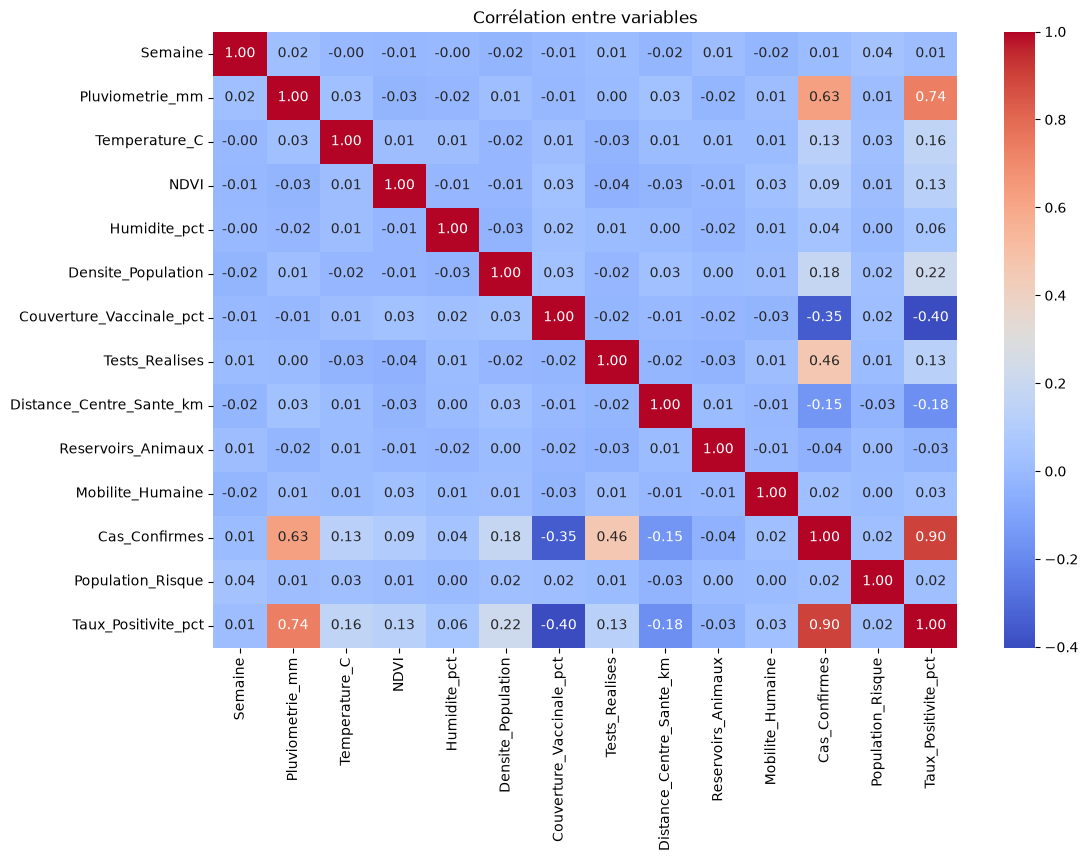

In [357]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Corrélation entre variables")
plt.show()

## 3.3 Corrélation avec les cas confirmés

In [358]:
corr_cas = corr["Cas_Confirmes"].sort_values(
    ascending=False
)

print(corr_cas)

Cas_Confirmes               1.000000
Taux_Positivite_pct         0.899874
Pluviometrie_mm             0.625170
Tests_Realises              0.462248
Densite_Population          0.181571
Temperature_C               0.131251
NDVI                        0.091674
Humidite_pct                0.042544
Mobilite_Humaine            0.024719
Population_Risque           0.022979
Semaine                     0.007926
Reservoirs_Animaux         -0.040024
Distance_Centre_Sante_km   -0.153797
Couverture_Vaccinale_pct   -0.350440
Name: Cas_Confirmes, dtype: float64


## 4. VISUALISATIONS ÉPIDÉMIOLOGIQUES

#### Boxplot de la variable dépendante

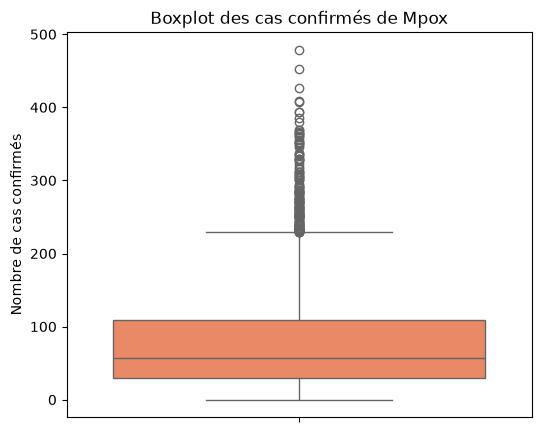

In [359]:
# ======================================================
# BOXPLOT DE LA VARIABLE DEPENDANTE
# ======================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.boxplot(
    y=MAK["Cas_Confirmes"],
    color="coral"
)

plt.title("Boxplot des cas confirmés de Mpox")
plt.ylabel("Nombre de cas confirmés")

plt.show()

### Boxplots de toutes les variables quantitatives

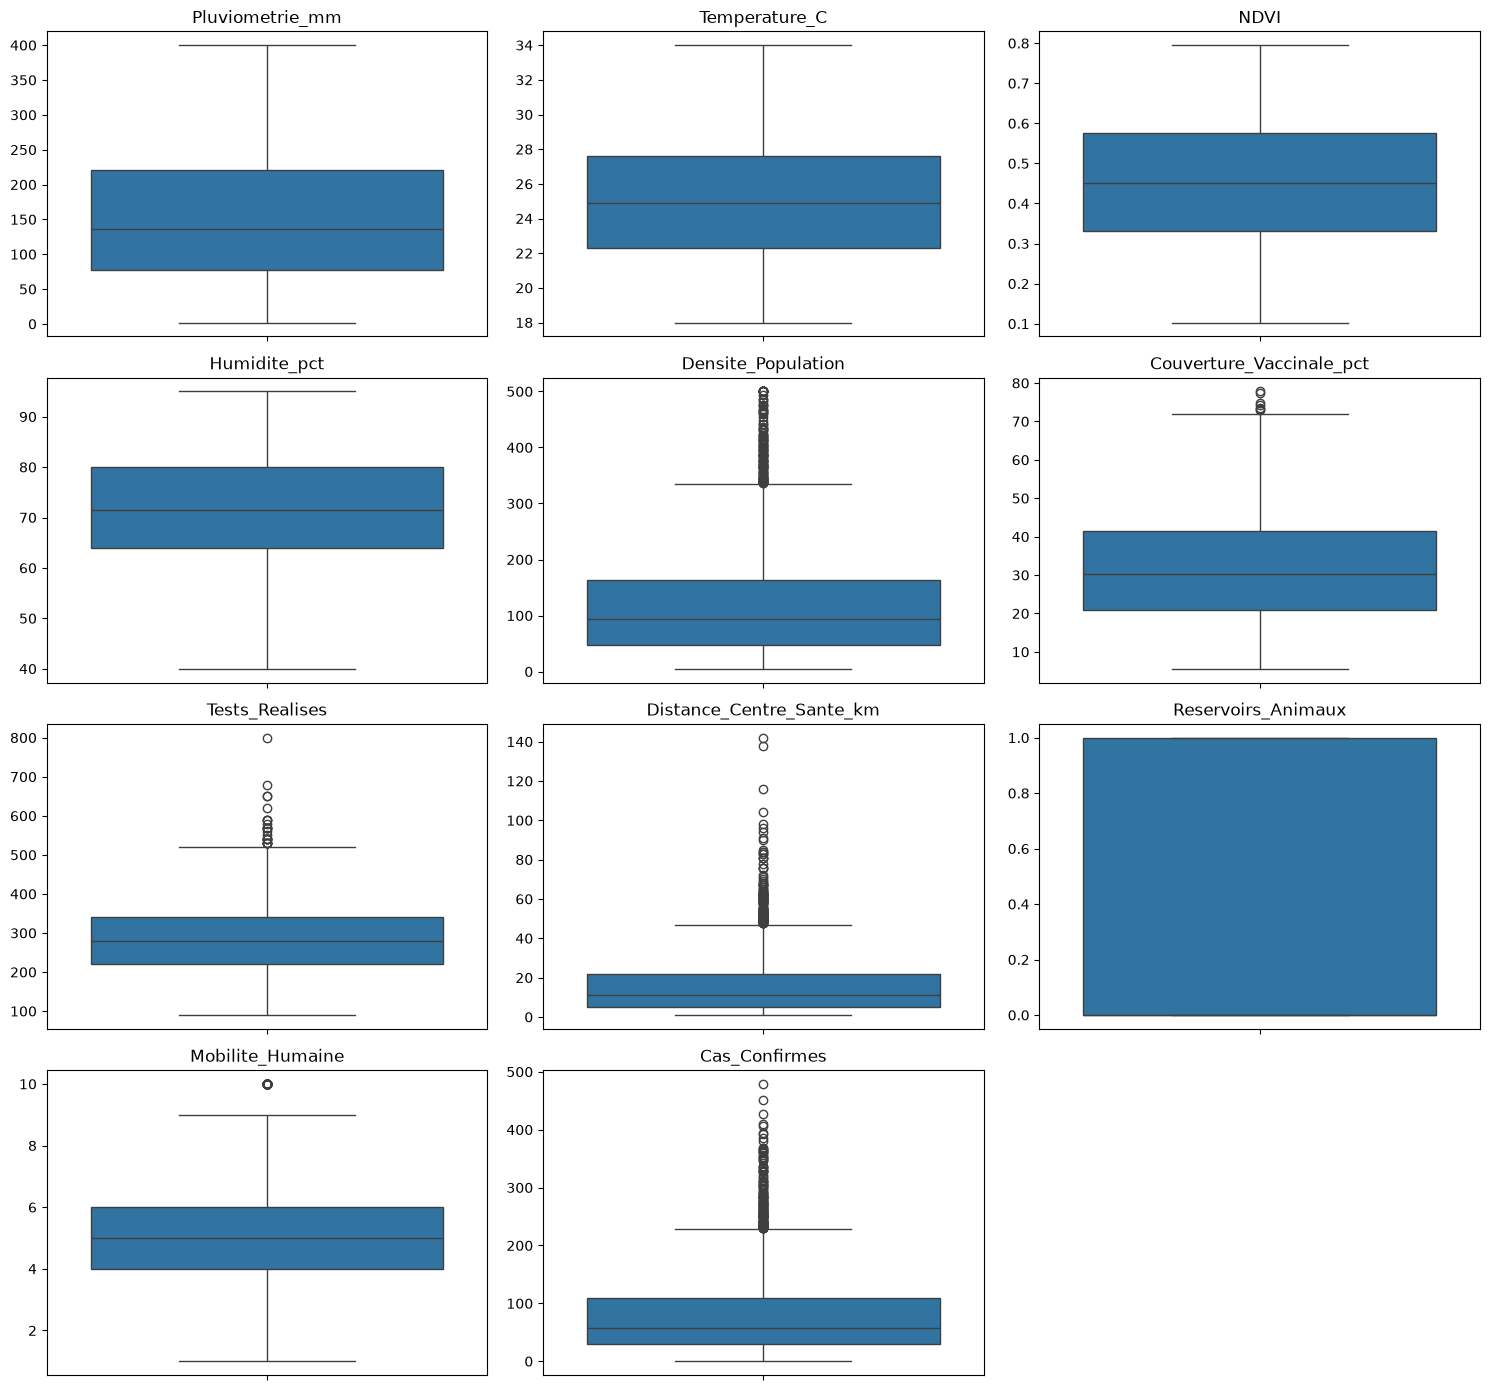

In [360]:
# ======================================================
# BOXPLOTS DES VARIABLES DU MODELE
# ======================================================

variables = [

    "Pluviometrie_mm",
    "Temperature_C",
    "NDVI",
    "Humidite_pct",
    "Densite_Population",
    "Couverture_Vaccinale_pct",
    "Tests_Realises",
    "Distance_Centre_Sante_km",
    "Reservoirs_Animaux",
    "Mobilite_Humaine",
    "Cas_Confirmes"

]

fig, axes = plt.subplots(4, 3, figsize=(15, 14))

axes = axes.flatten()

for i, var in enumerate(variables):

    sns.boxplot(
        y=MAK[var],
        ax=axes[i]
    )

    axes[i].set_title(var)
    axes[i].set_ylabel("")

# Supprimer les axes inutilisés
for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.show()

#### Boxplots des cas confirmés selon une variable catégorielle

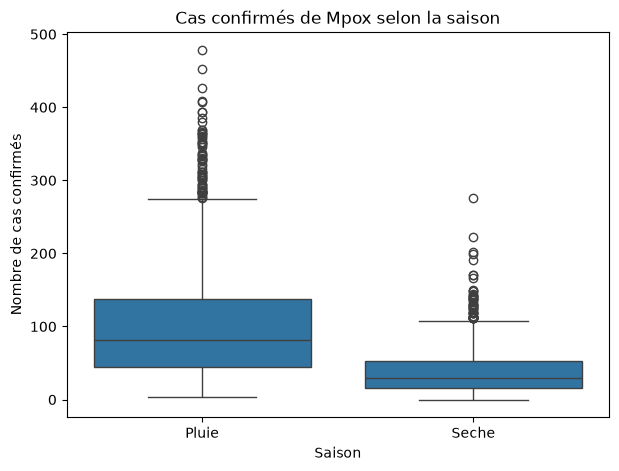

In [361]:
# ======================================================
# CAS CONFIRMES SELON LA SAISON
# ======================================================

plt.figure(figsize=(7,5))

sns.boxplot(
    x="Saison",
    y="Cas_Confirmes",
    data=MAK
)

plt.title("Cas confirmés de Mpox selon la saison")
plt.xlabel("Saison")
plt.ylabel("Nombre de cas confirmés")

plt.show()

#### 1. Résidus vs Valeurs prédites (Homoscédasticité)

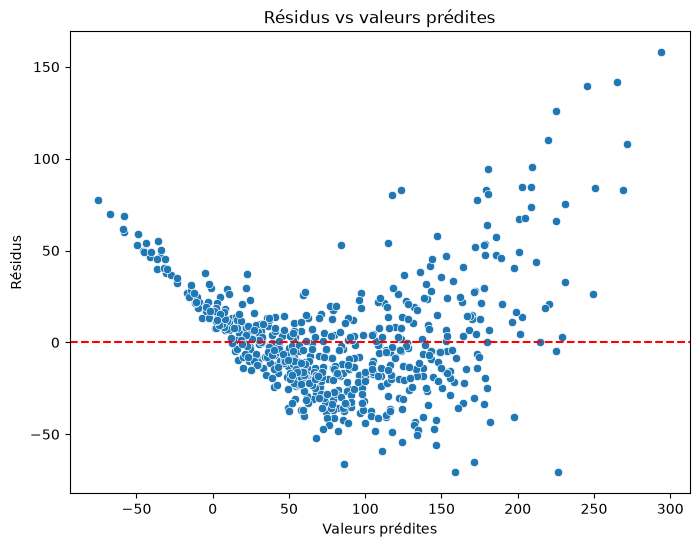

In [362]:
# ==========================================================
# RESIDUS VS VALEURS PREVUES
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Résidus
residus = y_test - y_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_pred,
    y=residus
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus vs valeurs prédites")

plt.show()

#### 2. Histogramme des résidus

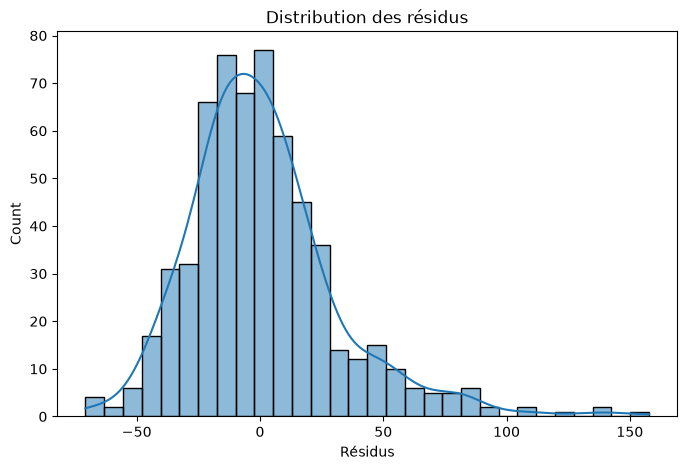

In [363]:
# ==========================================================
# HISTOGRAMME DES RESIDUS
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    residus,
    bins=30,
    kde=True
)

plt.xlabel("Résidus")
plt.title("Distribution des résidus")

plt.show()

#### 3. QQ-Plot (Normalité)

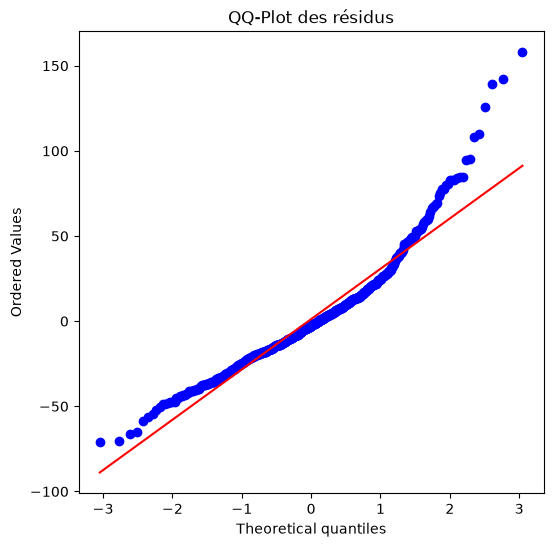

In [364]:
# ==========================================================
# QQ-PLOT
# ==========================================================

import scipy.stats as stats

plt.figure(figsize=(6,6))

stats.probplot(
    residus,
    dist="norm",
    plot=plt
)

plt.title("QQ-Plot des résidus")

plt.show()

#### 4. Résidus en fonction de chaque variable explicative

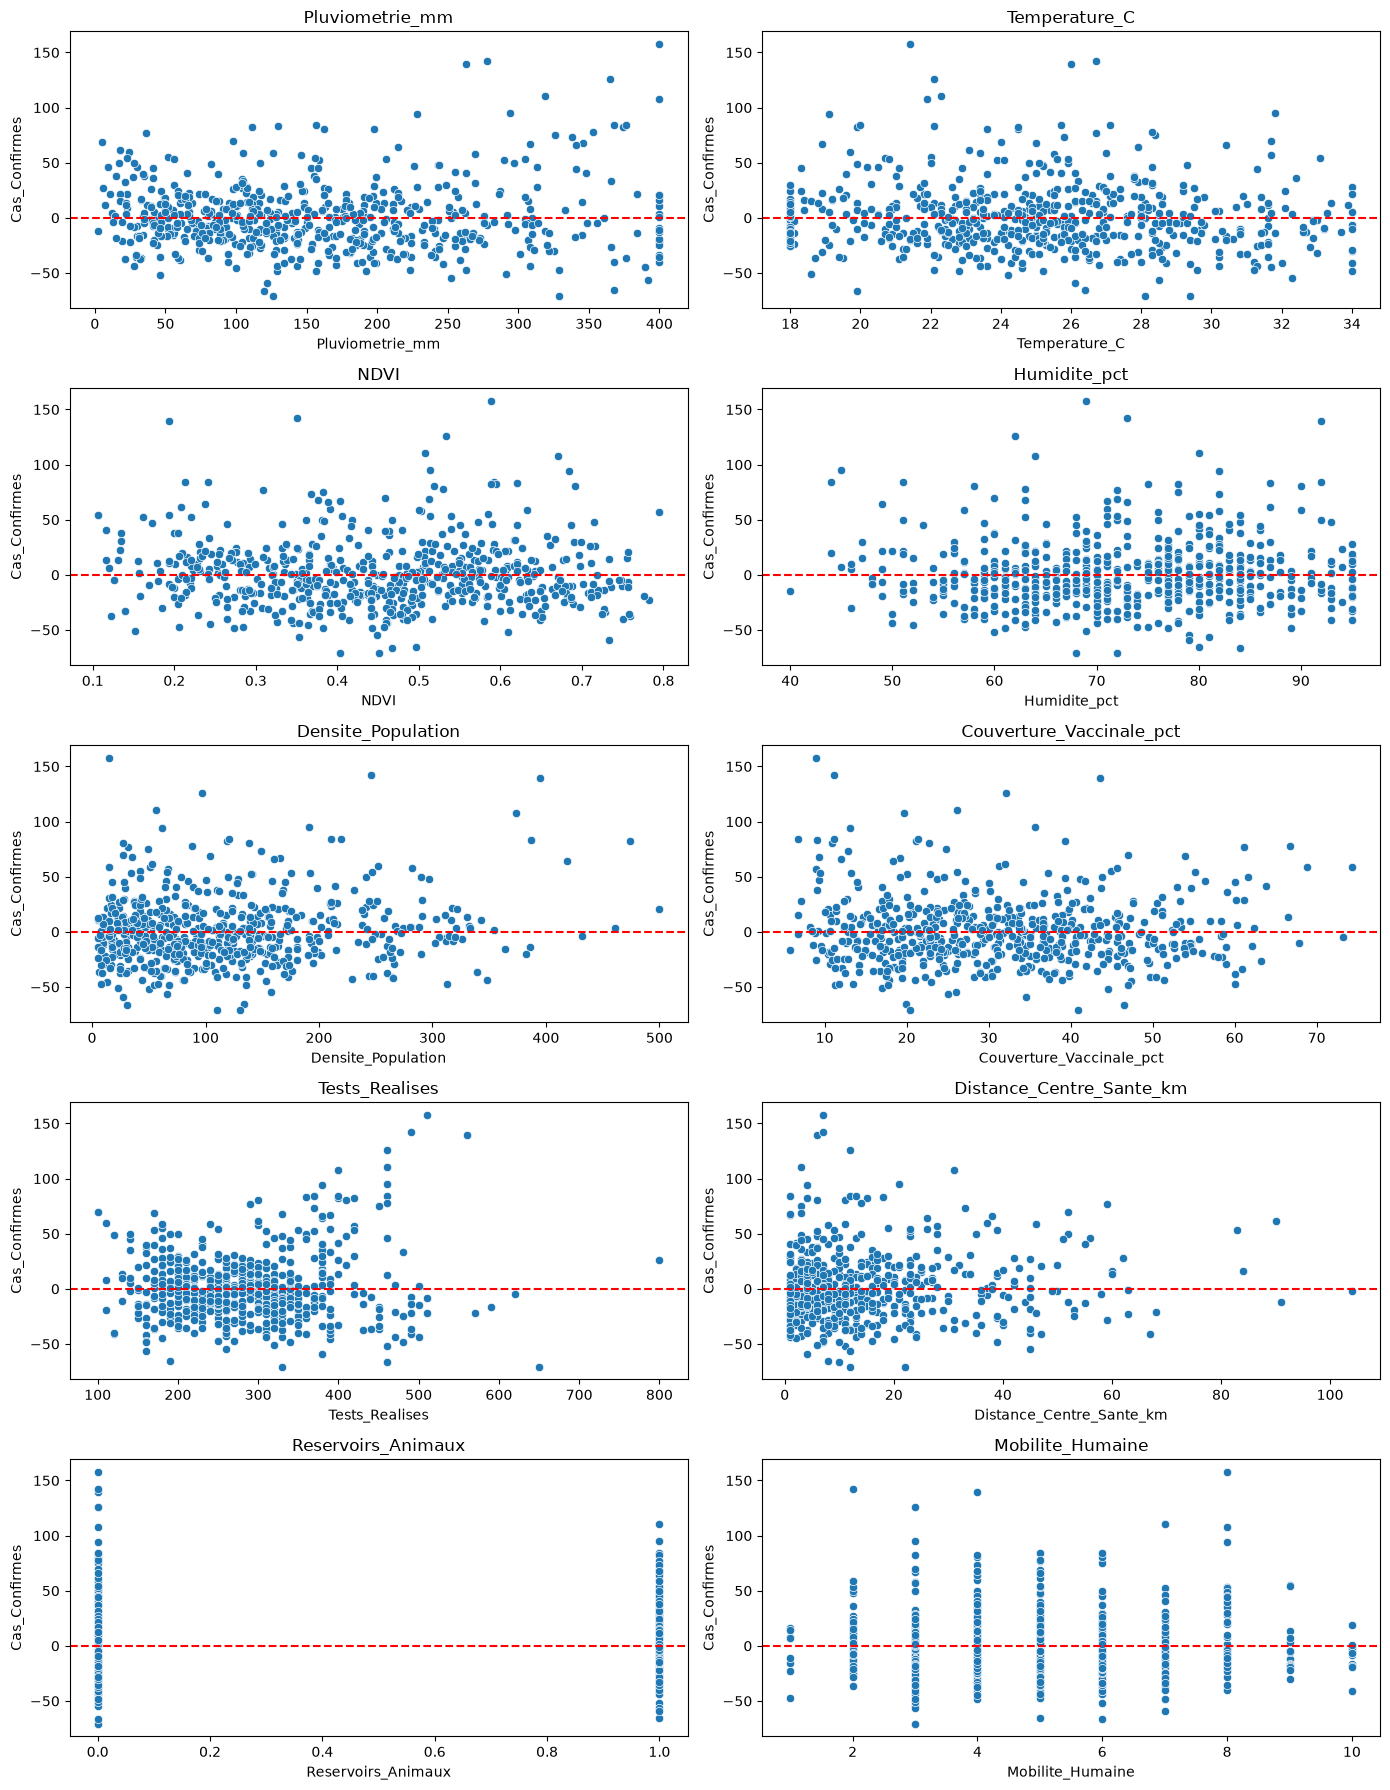

In [365]:
# ==========================================================
# RESIDUS SELON LES VARIABLES EXPLICATIVES
# ==========================================================

variables = X.columns

fig, axes = plt.subplots(5,2, figsize=(14,18))

axes = axes.flatten()

for i, var in enumerate(variables):

    sns.scatterplot(
        x=X_test[var],
        y=residus,
        ax=axes[i]
    )

    axes[i].axhline(
        y=0,
        color='red',
        linestyle='--'
    )

    axes[i].set_title(var)

plt.tight_layout()

plt.show()

#### 5. Valeurs observées vs valeurs prédites

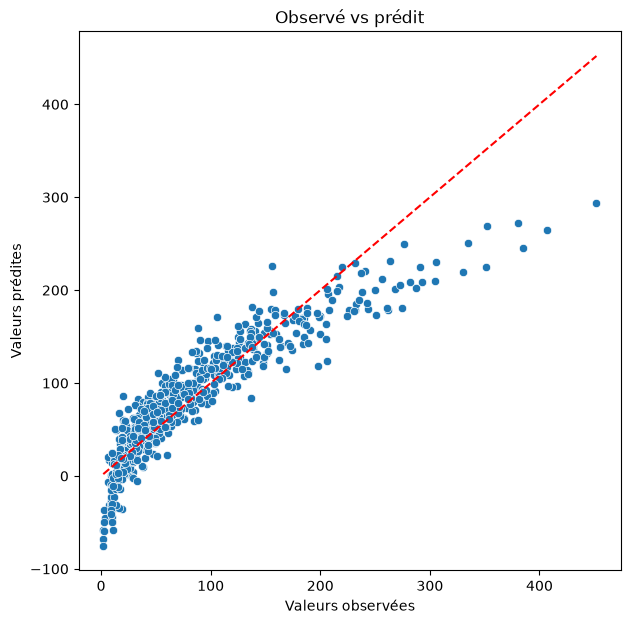

In [366]:
# ==========================================================
# OBSERVE VS PREDIT
# ==========================================================

plt.figure(figsize=(7,7))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Valeurs observées")
plt.ylabel("Valeurs prédites")

plt.title("Observé vs prédit")

plt.show()

#### 6. Influence des observations (Cook's Distance)

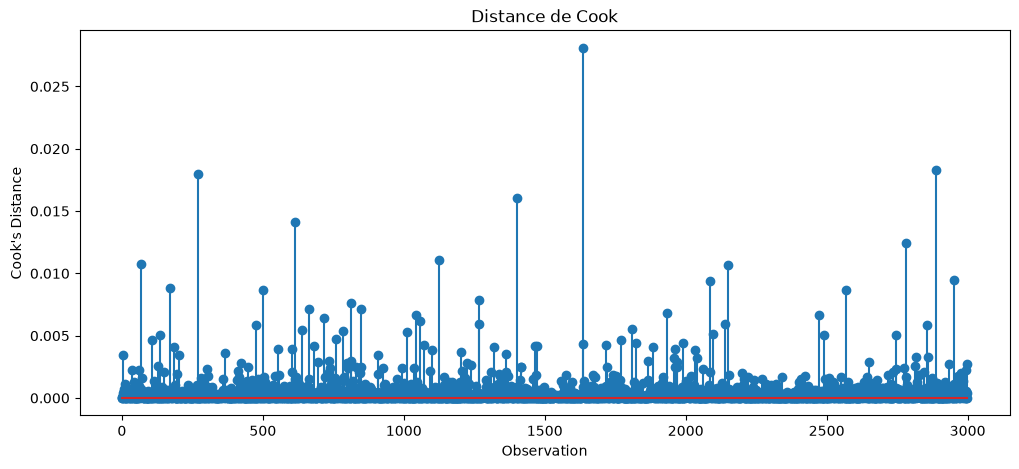

In [367]:
# ==========================================================
# COOK DISTANCE
# ==========================================================

import statsmodels.api as sm

X_const = sm.add_constant(X)

modele = sm.OLS(y, X_const).fit()

influence = modele.get_influence()

cooks = influence.cooks_distance[0]

plt.figure(figsize=(12,5))

plt.stem(cooks)

plt.title("Distance de Cook")

plt.xlabel("Observation")

plt.ylabel("Cook's Distance")

plt.show()

#### 7. Levene ou Breusch-Pagan (Homoscédasticité)

In [368]:
# ==========================================================
# TEST DE BREUSCH-PAGAN
# ==========================================================

from statsmodels.stats.diagnostic import het_breuschpagan

test = het_breuschpagan(
    modele.resid,
    modele.model.exog
)

labels = [
    "LM Statistic",
    "LM p-value",
    "F Statistic",
    "F p-value"
]

print(dict(zip(labels, test)))

{'LM Statistic': np.float64(371.87831848181116), 'LM p-value': np.float64(9.00148504397009e-74), 'F Statistic': np.float64(42.294247703935355), 'F p-value': np.float64(6.374998788470775e-79)}


### 4.1 Distribution des cas confirmés

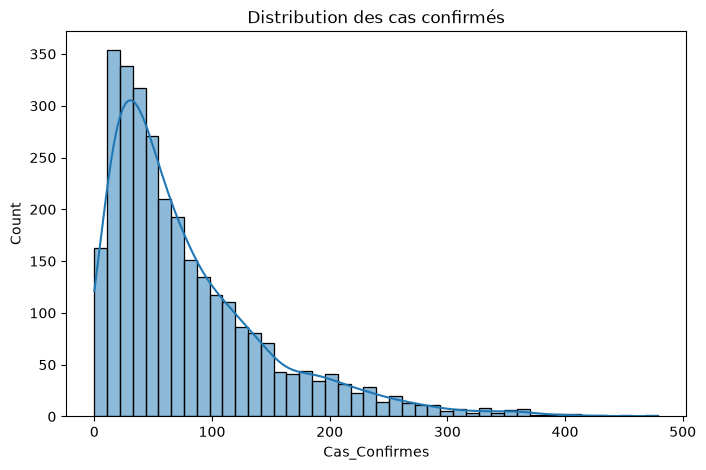

In [369]:
plt.figure(figsize=(8,5))

sns.histplot(
    MAK["Cas_Confirmes"],
    kde=True
)

plt.title(
    "Distribution des cas confirmés"
)

plt.show()

### 4.2 Cas confirmés par province

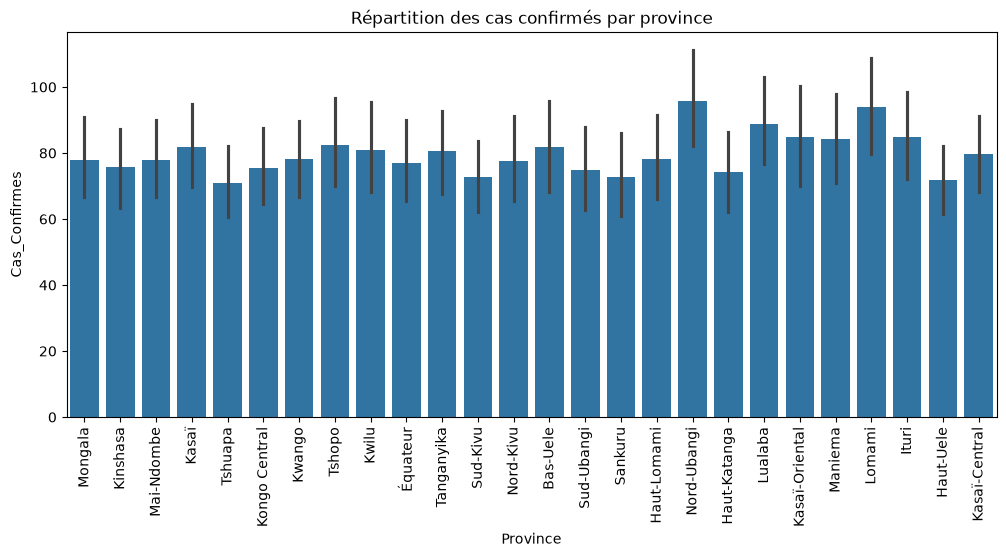

In [370]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=MAK,
    x="Province",
    y="Cas_Confirmes"
)

plt.xticks(
    rotation=90
)

plt.title(
    "Répartition des cas confirmés par province"
)

plt.show()

### 4.3 Relation NDVI - Cas confirmés

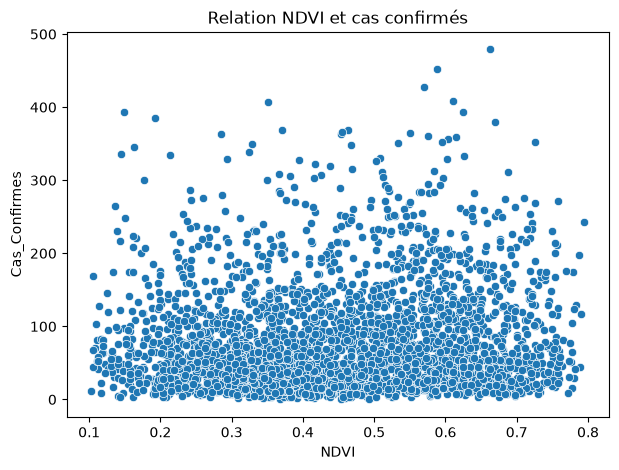

In [371]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=MAK,
    x="NDVI",
    y="Cas_Confirmes"
)

plt.title(
    "Relation NDVI et cas confirmés"
)

plt.show()

### 3.4 Relation pluie - cas

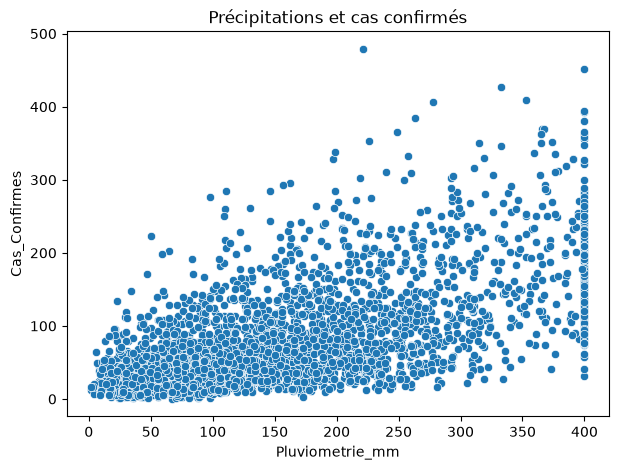

In [372]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=MAK,
    x="Pluviometrie_mm",
    y="Cas_Confirmes"
)

plt.title(
    "Précipitations et cas confirmés"
)

plt.show()

## 4. MODÉLISATION PAR RÉGRESSION
### Objectif :

### Prédire le nombre de cas confirmés selon les facteurs écologiques.

In [373]:
X = MAK[
[
'Pluviometrie_mm',
'Temperature_C',
'NDVI',
'Humidite_pct',
'Densite_Population',
'Couverture_Vaccinale_pct',
'Tests_Realises',
'Distance_Centre_Sante_km',
'Reservoirs_Animaux',
'Mobilite_Humaine'
]
]


y = MAK["Cas_Confirmes"]

### 4.2 Division apprentissage/test

In [374]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### 4.3 Régression linéaire

In [375]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 0.43, 2.59,60.79,...,-0.82,-2.64,-0.06]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['Pluviometrie_mm','Temperature_C','NDVI',...,'Distance_Centre_Sante_km', 'Reservoirs_Animaux','Mobilite_Humaine']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-158
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)


In [376]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

# Prédiction
y_pred = model.predict(X_test)

### 4.4 Évaluation

In [377]:
# Importation des métriques d'évaluation

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print("Importation réussie")

Importation réussie


In [378]:
print(
"MSE :",
mean_squared_error(y_test,y_pred)
)

print(
"RMSE :",
np.sqrt(mean_squared_error(y_test,y_pred))
)

print(
"MAE :",
mean_absolute_error(y_test,y_pred)
)

print(
"R² :",
r2_score(y_test,y_pred)
)

MSE : 933.2965647013062
RMSE : 30.549902859114074
MAE : 22.150635752135194
R² : 0.8257566956370467


### INTERPRETATION
#### Le modèle de régression linéaire multiple présente une bonne capacité explicative avec un coefficient de détermination R² de 0,826. Ainsi, les variables environnementales, démographiques et sanitaires considérées expliquent environ 82,6 % de la variabilité des cas confirmés. L'erreur moyenne de prédiction est estimée à 22 cas selon le MAE et à environ 31 cas selon le RMSE, indiquant une performance satisfaisante du modèle.

## 5. MACHINE LEARNING
### 5.1 Random Forest Regression

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(
    X_test
)

#### Créer le modèle

In [379]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

#### Entraîner le modèle

In [380]:
rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

#### Faire les prédictions

In [381]:
pred_rf = rf.predict(
    X_test
)

#### Évaluer Random Forest

In [382]:
## EVALUTION
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


print(
    "MSE Random Forest :",
    mean_squared_error(y_test, pred_rf)
)

print(
    "RMSE Random Forest :",
    np.sqrt(mean_squared_error(y_test, pred_rf))
)

print(
    "MAE Random Forest :",
    mean_absolute_error(y_test, pred_rf)
)

print(
    "R² Random Forest :",
    r2_score(y_test, pred_rf)
)

MSE Random Forest : 743.4752239999999
RMSE Random Forest : 27.266742086285262
MAE Random Forest : 18.67815
R² Random Forest : 0.8611956963720242


In [383]:
print(
"R² Random Forest :",
r2_score(
    y_test,
    pred_rf
)
)

R² Random Forest : 0.8611956963720242


### Random Forest améliore la capacité prédictive de 3,55 points de pourcentage par rapport à la régression linéaire.  
#### Random Forest peut capturer : des relations non linéaires ; des interactions entre variables ; des effets complexes.
#### Exemple : L'effet de la pluviométrie peut dépendre : du niveau de végétation (NDVI) ; de la densité humaine ; de la présence de réservoirs animaux.

## 5.2 Importance des variables

In [384]:
importance = pd.DataFrame(
{
"Variable":X.columns,
"Importance":rf.feature_importances_
}
)


importance.sort_values(
"Importance",
ascending=False
)

,Variable,Importance
0,Pluviometrie_mm,0.420965
6,Tests_Realises,0.265241
5,Couverture_Vaccinale_pct,0.149780
4,Densite_Population,0.044195
2,NDVI,0.034956
7,Distance_Centre_Sante_km,0.031247
1,Temperature_C,0.029121
3,Humidite_pct,0.014489
9,Mobilite_Humaine,0.007963
8,Reservoirs_Animaux,0.002043


##### Graphique :

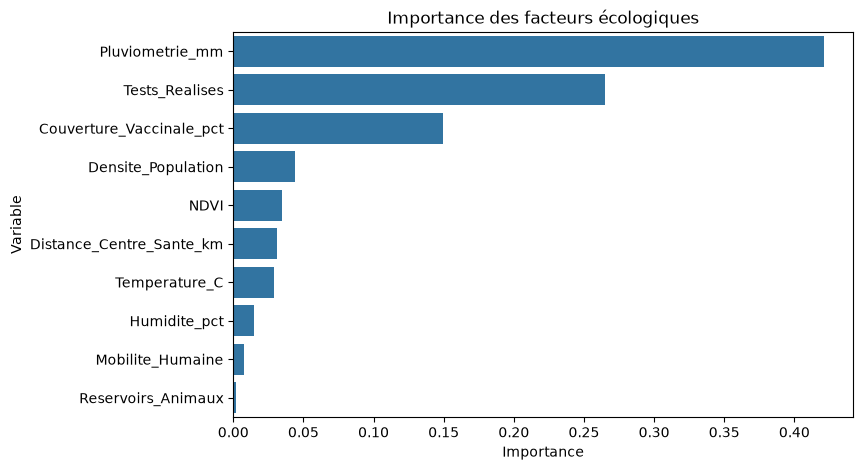

In [385]:
plt.figure(figsize=(8,5))

sns.barplot(
data=importance.sort_values(
"Importance",
ascending=False
),
x="Importance",
y="Variable"
)

plt.title(
"Importance des facteurs écologiques"
)

plt.show()

####  L'analyse de l'importance des variables issues du modèle XGBoost révèle une prédominance des facteurs environnementaux et sanitaires dans la prédiction des cas confirmés. La pluviométrie constitue le déterminant prédictif principal avec une contribution de 42,1 %, suivie du nombre de tests réalisés (26,5 %) et de la couverture vaccinale (15 %). Ces résultats suggèrent que la dynamique observée des cas résulte à la fois des conditions écologiques favorables et de l'intensité de la surveillance sanitaire. Les variables liées à la structure spatiale, telles que la densité de population, le NDVI et la distance aux centres de santé, présentent une contribution secondaire. La faible importance attribuée aux réservoirs animaux souligne davantage une limitation liée à la disponibilité et à la résolution des données qu'une absence d'effet écologique.

## 5.3 XGBoost

In [386]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [387]:
import xgboost as xgb

In [388]:
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)


xgb_model.fit(
    X_train,
    y_train
)


pred_xgb = xgb_model.predict(
    X_test
)

##### Performance :

In [389]:
print(
"R² XGBoost :",
r2_score(
    y_test,
    pred_xgb
)
)

R² XGBoost : 0.9008572101593018


#### INTERPRETATION : XGBoost présente la meilleure performance prédictive parmi les trois approches testées, avec un R² de 0,901. Cela signifie qu'environ 90 % de la variabilité des cas confirmés est expliquée par les variables environnementales, démographiques et sanitaires considérées.


## 6. Comparaison des modèles

In [390]:
resultats = pd.DataFrame({

"Modele":[
"Régression linéaire",
"Random Forest",
"XGBoost"
],

"R2":[

r2_score(y_test,y_pred),

r2_score(y_test,pred_rf),

r2_score(y_test,pred_xgb)

]

})


resultats

,Modele,R2
0,Régression linéaire,0.825757
1,Random Forest,0.861196
2,XGBoost,0.900857


#### Les performances des trois modèles montrent une amélioration progressive de la capacité prédictive avec l'utilisation des algorithmes d'apprentissage automatique. La régression linéaire multiple présente un coefficient de détermination de 0,826, indiquant une bonne capacité explicative des facteurs environnementaux et épidémiologiques. Le modèle Random Forest améliore cette performance avec un R² de 0,861. Le modèle XGBoost obtient la meilleure performance avec un R² de 0,901, traduisant une capacité supérieure à capturer les relations non linéaires et les interactions complexes entre les déterminants écologiques et la dynamique des cas confirmés.